<a href="https://colab.research.google.com/github/Muskan-Sh-23/Machine-learning/blob/main/Support_Vector_Machine/Polynomial_SVM_using_Sklearn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Polynomial Kernel SVM on Two Moons Dataset

A nonlinear Support Vector Machine using a Polynomial Kernel to classify the Two Moons dataset.

In [114]:
# Libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

## Dataset

The Two Moons dataset contains two interleaving classes that cannot be separated by a single straight line, making it useful for testing nonlinear classifiers.

In [115]:
# Uploading the data

from sklearn.datasets import make_moons
# Instead of drawing a straight line in the original space, a kernel maps the data into a higher-dimensional space where a straight hyperplane becomes possible.
# When transformed back, that hyperplane appears as a curved boundary that follows the moon shapes.
X, Y = make_moons(n_samples=300, noise=0.15, random_state=42)

## Feature Standardization

Features are standardized using `StandardScaler` so both features contribute equally to distance calculations.

In [116]:
# Standardize
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)   # Learn mean & std from training data
X_test = scaler.transform(X_test)         # Use the same values for test data

# Verification
print("Train Mean:", np.mean(X_train, axis=0))
print("Train Std:", np.std(X_train, axis=0))

Train Mean: [ 1.85037171e-17 -3.12712819e-16]
Train Std: [1. 1.]


In [117]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=42,
    stratify=Y
)

In [118]:
# Data Inspection

print("Shape of X:", X.shape)
print("Shape of Y:", Y.shape)

print("\nFirst five samples:")
print(X[:5])

print("\nUnique labels:")
print(set(Y))

Shape of X: (300, 2)
Shape of Y: (300,)

First five samples:
[[ 0.74345732 -0.31830534]
 [ 2.17771154 -0.1269264 ]
 [-0.21007181  0.45266402]
 [ 0.83759707  0.33520083]
 [ 1.18455753 -0.5045741 ]]

Unique labels:
{np.int64(0), np.int64(1)}


## Data Visualization

Plotting the dataset helps visualize why a linear decision boundary is insufficient.

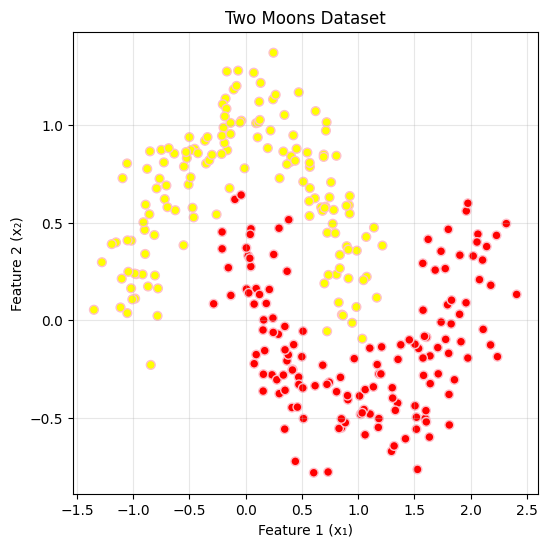

In [119]:
# Visualize the data

plt.figure(figsize=(6,6))
plt.scatter(
    X[:,0],      # x₁ coordinates
    X[:,1],      # x₂ coordinates
    c=Y,         # color according to class
    cmap="autumn_r",
    edgecolors="pink",
    s=40
)

plt.xlabel("Feature 1 (x₁)")
plt.ylabel("Feature 2 (x₂)")
plt.title("Two Moons Dataset")
plt.grid(alpha=0.3)

plt.show()

## Polynomial Kernel

Instead of learning a straight boundary in the original space, the Polynomial Kernel maps the data into a higher-dimensional feature space where a linear separator becomes possible.

<math value="K(x,z)=(x\\cdot z+c)^d" block/>

- `degree`: Controls the complexity of the boundary.
- `coef0`: Adds a constant before raising to the power.
- `C`: Controls the trade-off between margin size and classification errors.

## Model Training

A Polynomial Kernel SVM is trained with degree 3 on the standardized training data.


In [120]:
poly_svm = SVC(
    kernel="poly",
    degree=3,
    coef0=1,
    C=1
)

poly_svm.fit(X_train, Y_train)

SVC(C=1, coef0=1, kernel='poly')

In [121]:
Y_pred = poly_svm.predict(X_test)

## Model Evaluation

Performance is measured using both training accuracy and test accuracy to evaluate how well the model generalizes.

In [122]:
# Predictions
train_pred = poly_svm.predict(X_train)
test_pred = poly_svm.predict(X_test)

# Accuracy
train_accuracy = accuracy_score(Y_train, train_pred)
test_accuracy = accuracy_score(Y_test, test_pred)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Training Accuracy: 0.9708
Test Accuracy: 0.9500


## Decision Boundary

The learned boundary curves around the two moon-shaped classes instead of using a single straight line.

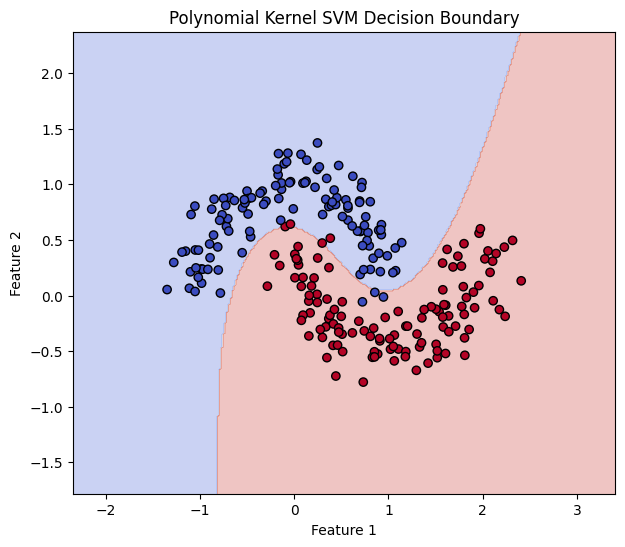

In [123]:
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

Z = poly_svm.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(7,6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
plt.scatter(X_train[:,0], X_train[:,1], c=Y_train, cmap="coolwarm", edgecolors="k")
plt.title("Polynomial Kernel SVM Decision Boundary")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

## Observations

- Polynomial Kernel captures nonlinear patterns.
- Degree 3 provides a flexible curved decision boundary.
- Standardization improves SVM performance.
- Test accuracy indicates how well the model performs on unseen data.

In [124]:
for d in [2, 3, 5]:
    model = SVC(kernel="poly", degree=d, coef0=1, C=1)
    model.fit(X_train, Y_train)

    score = model.score(X_test, Y_test)
    print(f"Degree {d}: {score:.4f}")

Degree 2: 0.8167
Degree 3: 0.9500
Degree 5: 0.9833


## Conclusion

Polynomial Kernel SVM successfully classifies the Two Moons dataset by learning a nonlinear decision boundary through the kernel trick.